In [1]:
# Import modules
import sys
sys.path.append(r"c:/Users/Raees/Desktop/stuff/NuOscProbExact/src")

from oscprob2nu import *
from globaldefs import *
from hamiltonians2nu import *

import numpy as np 
import matplotlib.pyplot as plt
from NuOscProbExact.src import  oscprob2nu, globaldefs, hamiltonians2nu
import math
from scipy.stats import truncnorm
from scipy.optimize import curve_fit
import copy as cp

In [2]:
def gaus(x,p0,p1,p2):
    return p0 * math.e**((-0.5 * (x - p1)**2)/ p2**2)

# Function to generate counts from a Poisson distribution based on probabilities and Gaussian scaling    
def poisson_dist(probability, bin_centers, amplitude, mean, sigma):
    counts = np.random.poisson(probability * gaus(bin_centers,amplitude,mean,sigma)) 
    return counts


In [3]:
# parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5])
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

length_nd = 1 # [km]
length_fd = 810 # [km]

Fitted parameters for observed the unoscillated ND events: Amplitude = 212.76692699546734, Mean = 1.8044188236655974, Sigma = 0.5254484171717854
Fitted parameters for observed the oscillated FD events: Amplitude = 13.876745944019577, Mean = 2.211417891318019, Sigma = 0.4952413577763477


Text(0.5, 0, 'Energy (GeV)')

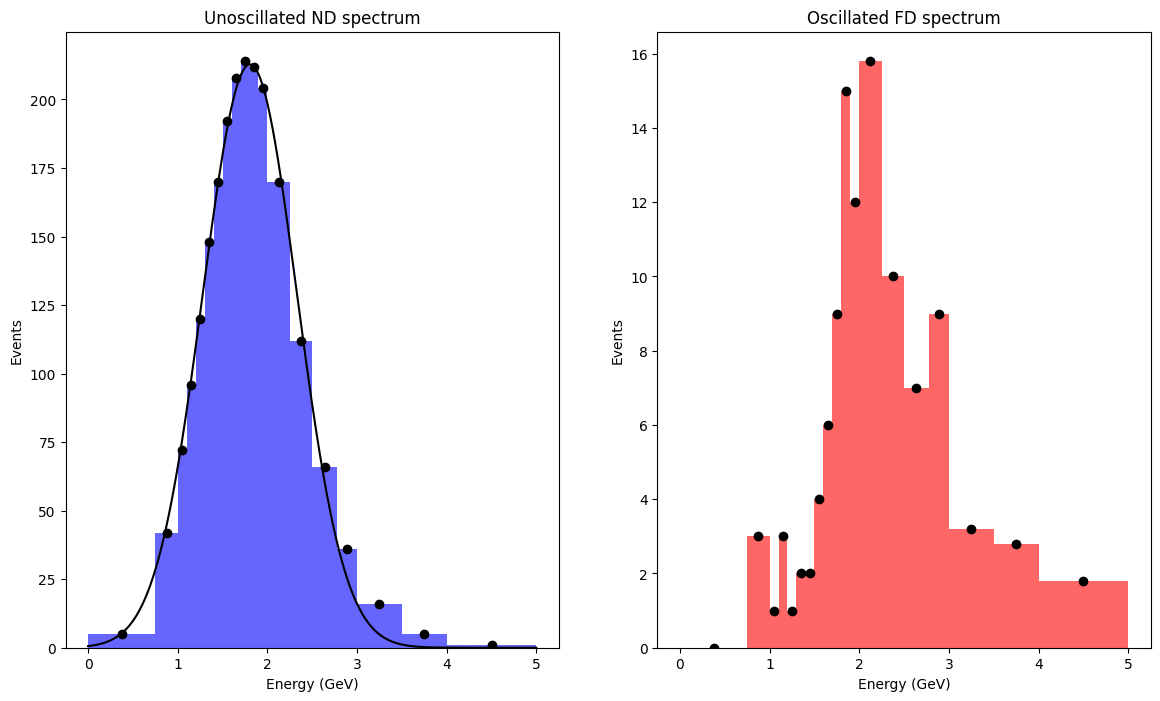

In [4]:
initial_guess_nd = [140,2,0.5]
initial_guess_fd = [8, 2, 0.5]

popt_nd, _ = curve_fit(gaus, bin_centers, counts_nd, p0=initial_guess_nd)
popt_fd, _ = curve_fit(gaus, bin_centers, counts_fd, p0=initial_guess_fd)

print(f"Fitted parameters for observed the unoscillated ND events: Amplitude = {popt_nd[0]}, Mean = {popt_nd[1]}, Sigma = {popt_nd[2]}")
print(f"Fitted parameters for observed the oscillated FD events: Amplitude = {popt_fd[0]}, Mean = {popt_fd[1]}, Sigma = {popt_fd[2]}")

fig, axs = plt.subplots(1, 2, figsize=(14, 8))

x = np.arange(0,5,0.001)

axs[0].hist(bin_edges[:-1],bin_edges ,weights=counts_nd, density=False, alpha=0.6, color='b')
axs[0].scatter(bin_centers, counts_nd, color='black')
axs[0].plot(x, gaus(x,*popt_nd), color='black')
axs[0].set_title("Unoscillated ND spectrum")
axs[0].set_ylabel("Events")
axs[0].set_xlabel("Energy (GeV)")

axs[1].hist(bin_edges[:-1], bin_edges,weights=counts_fd, density=False, alpha=0.6, color='r')
axs[1].scatter(bin_centers, counts_fd, color='black')
#axs[1].plot(x, gaus(x, *popt_fd), color='black')
axs[1].set_title("Oscillated FD spectrum")
axs[1].set_ylabel("Events")
axs[1].set_xlabel("Energy (GeV)")

In [ ]:
def osc_probability_2nu(sector, case, length, transition):
    """
    Calculate oscillation probabilities for 2-neutrino systems.

    Parameters:
    - sector: str, '12' or '23'
    - case: str, 'vacuum' or 'matter'
    - length: float, in kilometers
    - transition: str, 'me', 'mm', or 'mt'

    Returns:
    - List of probabilities for the specified transition
    """
    # Convert energy to eV
    energy = bin_centers * 1e9
    probabilities = []

    # Sector-specific parameters
    if sector == '12':
        mixing_angle = globaldefs.S12_NO_BF
        delta_mass_squared = globaldefs.D21_NO_BF
        transition_map = {'me': 2, 'mm': 3}
    elif sector == '23':
        mixing_angle = globaldefs.S23_NO_BF
        delta_mass_squared = globaldefs.D31_NO_BF
        transition_map = {'mm': 0, 'mt': 1}
    else:
        raise ValueError(f"Invalid sector '{sector}'. Must be '12' or '23'.")

    # Determine the index for the transition
    index1 = transition_map.get(transition)
    if index1 is None:
        raise ValueError(f"Invalid transition '{transition}'. Must match the sector.")

    # Calculate energy-independent vacuum Hamiltonian
    h_vacuum_energy_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(mixing_angle, delta_mass_squared)

    # Scaling factor for length
    length_scaled = length * globaldefs.CONV_KM_TO_INV_EV

    # Define a function for Hamiltonian calculation
    if case == 'vacuum':
        def calculate_hamiltonian(e): return h_vacuum_energy_indep / e
    elif case == 'matter':
        def calculate_hamiltonian(e): return hamiltonians2nu.hamiltonian_2nu_matter(h_vacuum_energy_indep, e, globaldefs.VCC_EARTH_CRUST)
    else:
        raise ValueError(f"Invalid case '{case}'. Must be 'vacuum' or 'matter'.")
    
    # Compute probabilities
    probabilities = [
        oscprob2nu.probabilities_2nu(calculate_hamiltonian(e), length_scaled)[index1]
        for e in energy
    ]

    return probabilities


In [7]:
def plot_osc_2nu(sector, case, length, transition):
    # Calculate the oscillation probabilities based on the specified sector, case, and length
    """
    Parameters:
    - sector: str, oscillation sector ('12' or '23')
    - case: str, either 'vacuum' or 'matter'
    - length: int, detector length (1, 810)
    - transition: str, type of transition ('me', 'mm', 'mt')
    """
    # Calculate the oscillatoin probabilities
    probabilities = osc_probability_2nu(sector, case, length, transition)
    print(f'Probabilitities: ', probabilities)
    
    popt = popt_nd
    weights = counts_nd

    # Maps the lengths to their repestive titles
    title_map = {
        length_nd: 'Unoscillated vs Oscillated Neutrino Events in ND',
        length_fd: 'Unoscillated vs Oscillated Neutrino Events in FD'
    }
    title_text1 = title_map.get(length, 'Unknown')
    fit_oscillation = (length == length_nd)
    title_text2 = 'In Matter' if case == 'matter' else 'In Vacuum'
    full_title = f'{title_text1} {title_text2}'

    # Set labels and event index based on the transition type
    label_map = {
        'me': ('μ → e events', 'Gaussian (μ → e) events fit', 2),
        'mt': ('μ → τ events', 'Gaussian (μ → τ) events fit', 2),
        'mm': ('μ → μ events', 'Gaussian (μ → μ) events fit', 0),
    }
    event_label, gaussian_fit_label, index = label_map.get(transition, ('Unknown transition', '', 0))

    # Calculate the Poisson-distributed counts for the oscillated events
    counts = poisson_dist(probabilities, bin_centers, *popt)
    counts_without_poisson_dist = probabilities * gaus(bin_centers, *popt)
    
    # Start plotting
    fig, axs = plt.subplots(1, 2, figsize=(14, 8))
    x = np.arange(0,5,0.001)

    # First subplot: with Poisson dist
    axs[0].hist(bin_edges[:-1],bin_edges ,weights=weights, histtype='step', alpha=0.6, color='r', label='Unoscillated Events')
    axs[0].plot(x, gaus(x,*popt_nd), color='green', label='Gaussian Unoscillated Events')
    axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=counts, histtype='step',density=False,
                alpha=0.6, color='b', label=event_label)

    if fit_oscillation:
        popt_osc, _ = curve_fit(gaus, bin_centers, counts)
        print(f"Fitted parameters for observed events: Amplitude = {popt_osc[0]}, Mean = {popt_osc[1]}, Sigma = {popt_osc[2]}")
        axs[0].plot(x, gaus(x, *popt_osc), color='black',label=gaussian_fit_label)

    axs[0].set_title(full_title)
    axs[0].set_xlabel('Energy (GeV)')
    axs[0].set_ylabel('Events')
    axs[0].legend()
    axs[0].grid()

    # Second subplot: without Poisson dist
    axs[1].hist(bin_edges[:-1],bin_edges ,weights=weights, histtype='step', alpha=0.6, color='r', label='Unoscillated Events')
    axs[1].plot(x, gaus(x,*popt_nd), color='green', label='Gaussian Unoscillated Events')
    axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=counts_without_poisson_dist, histtype='step',density=False, 
                alpha=0.6, color='b', label=event_label)
    
    if fit_oscillation:
        popt_unfluc, _ = curve_fit(gaus, bin_centers, counts_without_poisson_dist)
        axs[1].plot(x, gaus(x, *popt_unfluc), color='black',label=gaussian_fit_label)

    axs[1].set_title(full_title + ' (No Poisson Fluctuations)')
    axs[1].set_xlabel('Energy (GeV)')
    axs[1].set_ylabel('Events')
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()

Probabilitities:  [0.9999291865250836, 0.9999869931858231, 0.9999909674778581, 0.9999924700485543, 0.9999936266465712, 0.9999945358749882, 0.999995263557519, 0.9999958549959068, 0.9999963421950429, 0.9999967482855899, 0.9999970903209503, 0.999997381097294, 0.9999977946842462, 0.9999982345253494, 0.9999985684588806, 0.9999988056137, 0.9999990571944846, 0.9999992918482448, 0.9999995082279113]
Fitted parameters for observed events: Amplitude = 217.0074063635208, Mean = 1.8040467528006507, Sigma = -0.5064558032988711


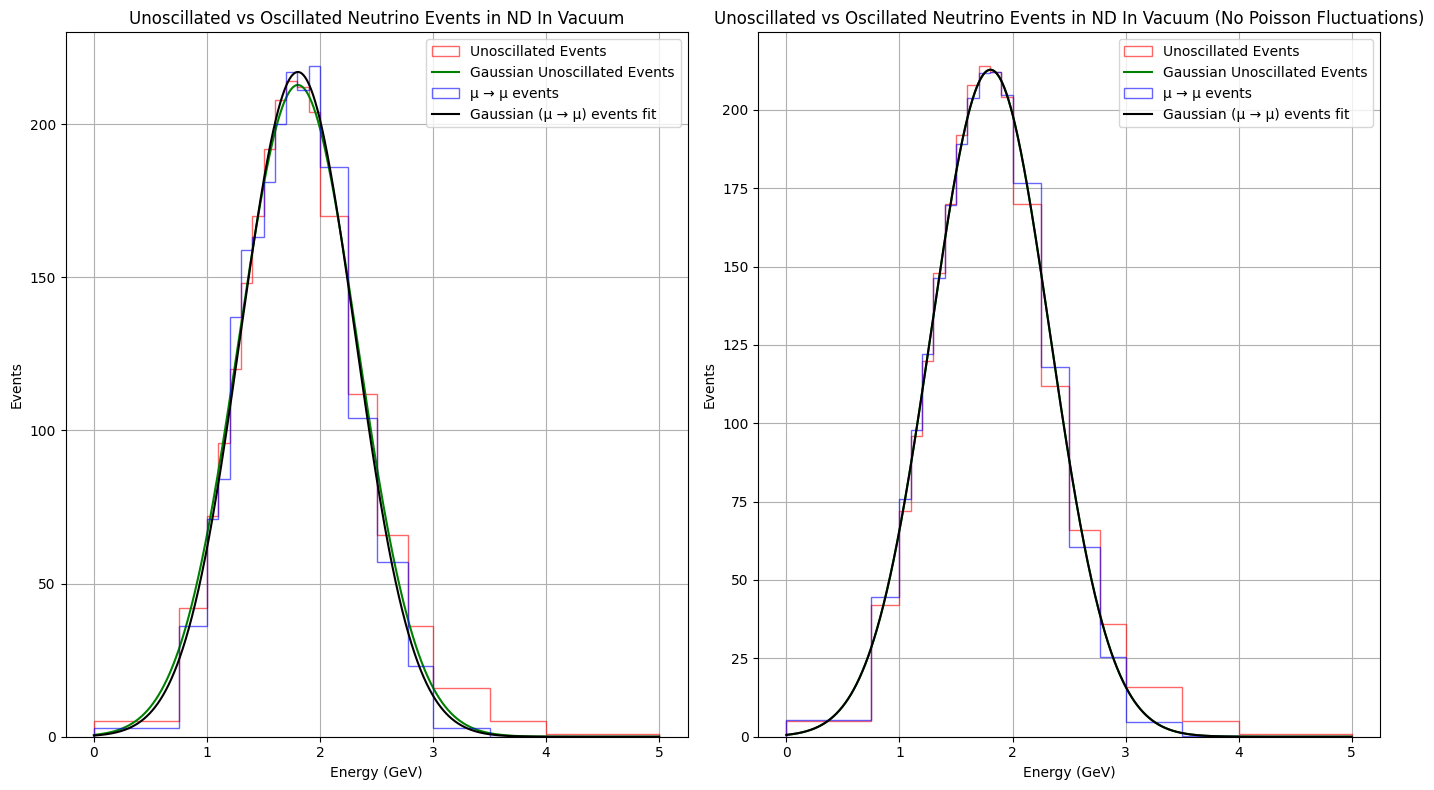

In [8]:
plot_osc_2nu(sector='23', case='vacuum', length=length_nd, transition='mm')

Probabilitities:  [0.6653307341929288, 0.9687321181467963, 0.621155521490715, 0.4139422689541826, 0.2523328466200332, 0.14044032234507176, 0.07169074747223192, 0.03677751611967128, 0.02689613750418407, 0.034776793974110154, 0.054797882961059696, 0.08277152749360017, 0.142198564280958, 0.23421531669891948, 0.32662760204792696, 0.40538378945036035, 0.5018767392901122, 0.6047768472581979, 0.7114690487256135]


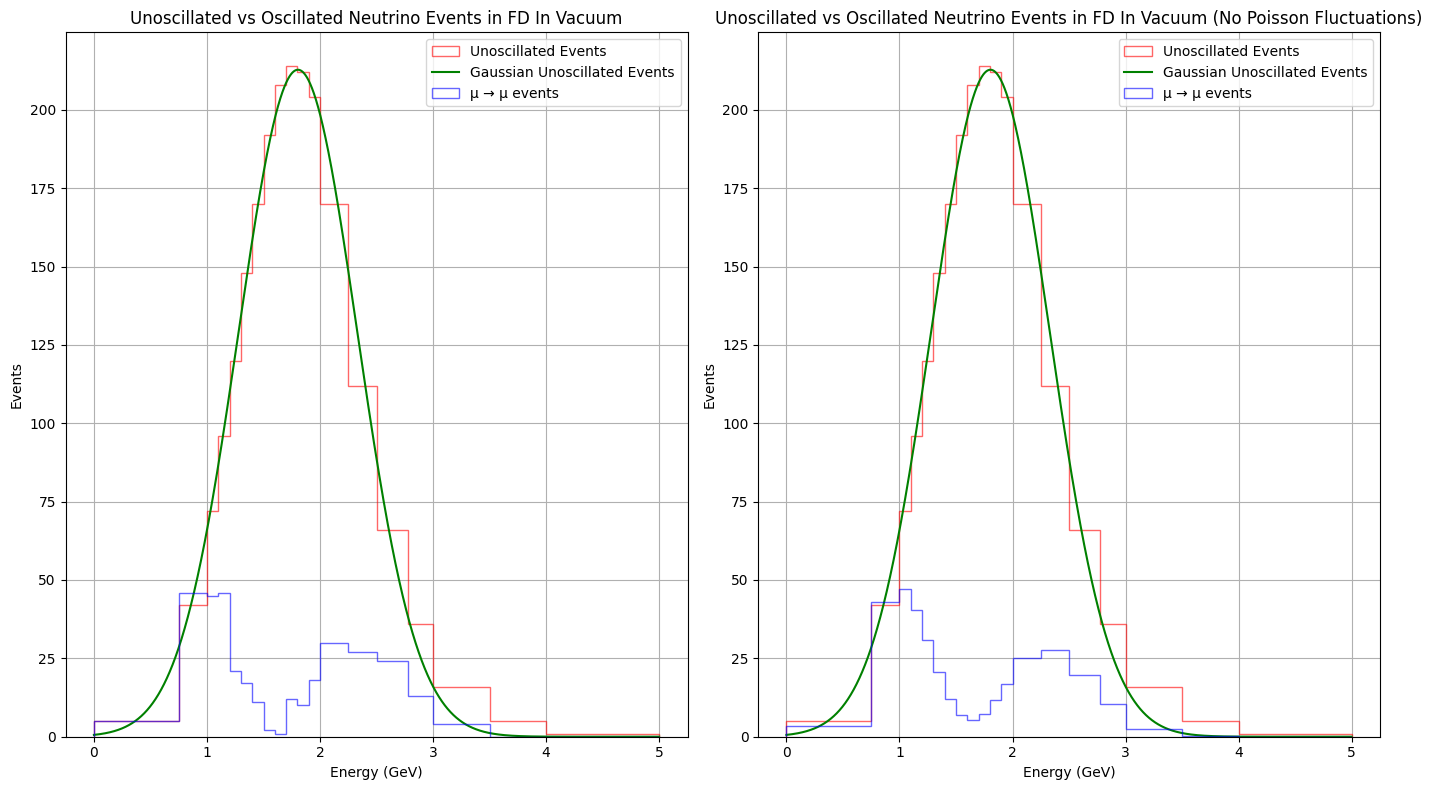

Probabilitities:  [0.33466926580707124, 0.031267881853203706, 0.378844478509285, 0.5860577310458174, 0.7476671533799668, 0.8595596776549282, 0.9283092525277681, 0.9632224838803287, 0.9731038624958159, 0.9652232060258898, 0.9452021170389403, 0.9172284725063998, 0.857801435719042, 0.7657846833010805, 0.673372397952073, 0.5946162105496396, 0.49812326070988777, 0.3952231527418021, 0.28853095127438655]


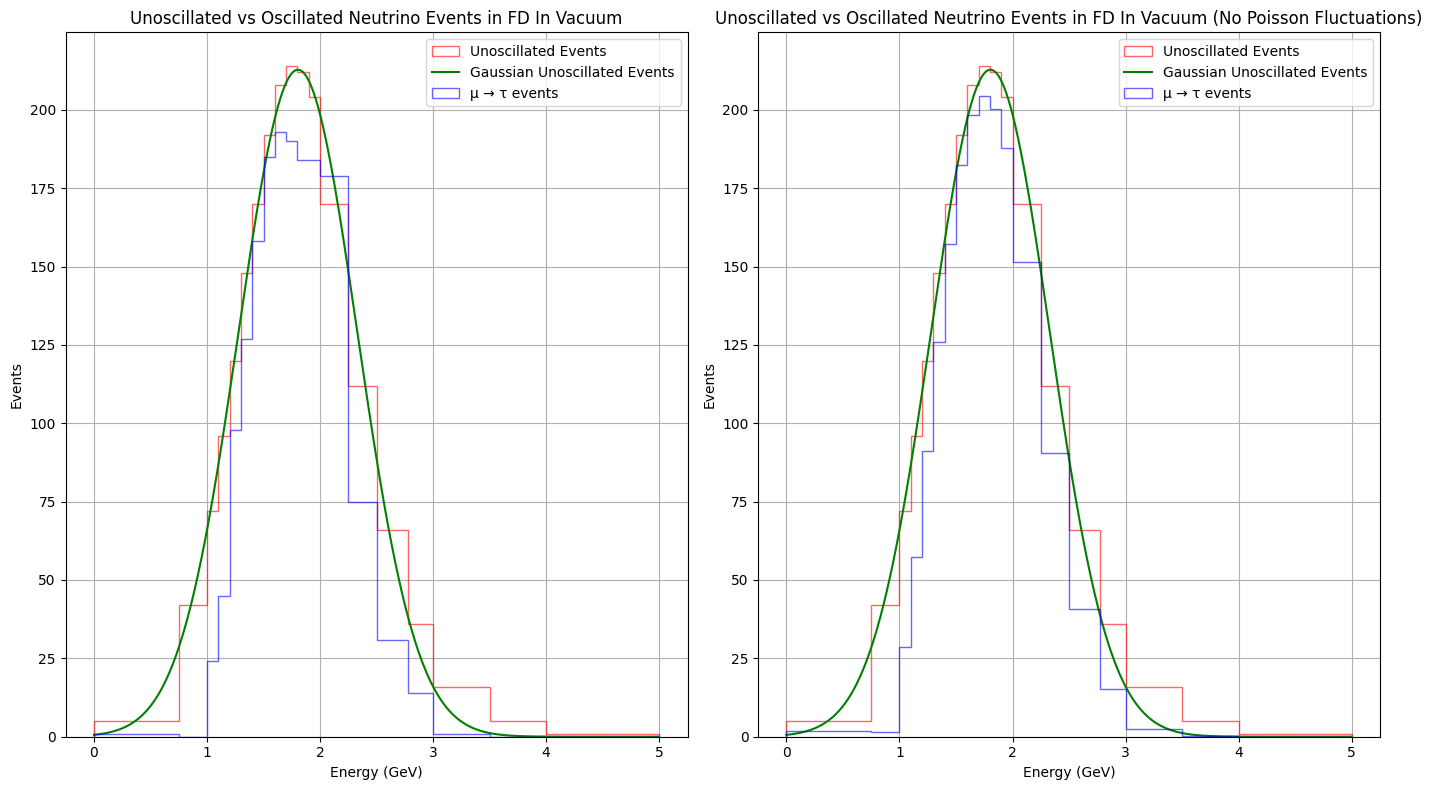

Probabilitities:  [0.034517982761426806, 0.006411103781786138, 0.004455564502644847, 0.003715449117993671, 0.003145456607042997, 0.0026971942324509448, 0.0023383235628732773, 0.002046570316452103, 0.001806187856032761, 0.0016057896908078068, 0.0014369772940009849, 0.0012934464503434578, 0.001089267106492091, 0.0008720910035609608, 0.0007071833359541512, 0.0005900554118094981, 0.00046579100384905016, 0.0003498766037303638, 0.00024297998517533925]


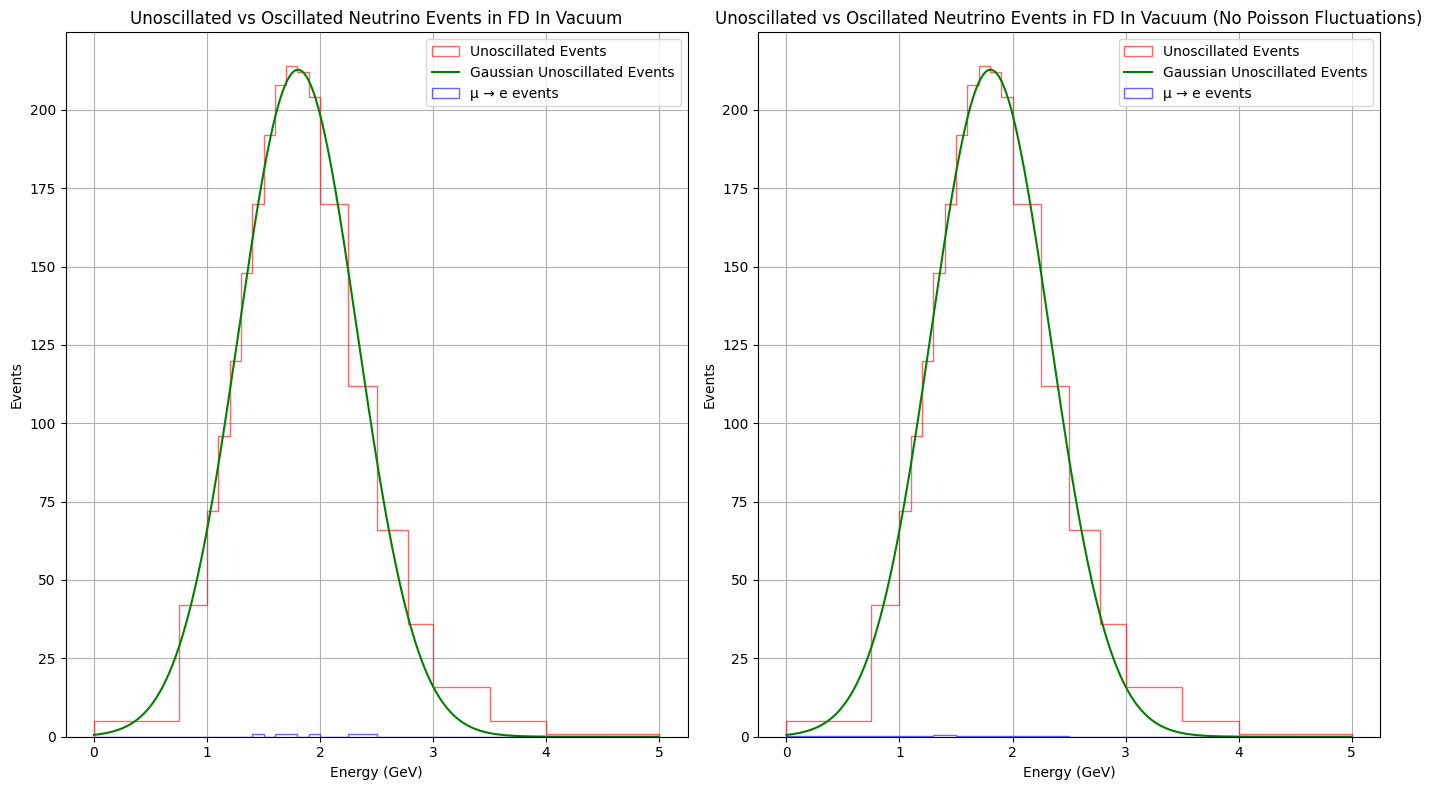

In [9]:

plot_osc_2nu(sector='23', case='vacuum', length=length_fd, transition='mm')
plot_osc_2nu(sector='23', case='vacuum', length=length_fd, transition='mt')
plot_osc_2nu(sector='12', case='vacuum', length=length_fd, transition='me')

Probabilitities:  [0.6936888461357653, 0.957099576809959, 0.5859002569242262, 0.37448809740216604, 0.2128432058525468, 0.10325345416035725, 0.037925388152265316, 0.006816143658961549, 0.0007092601600106052, 0.01212365039796759, 0.035344491171448, 0.06615712826033149, 0.12972056654438235, 0.22609277293613628, 0.3216174749859525, 0.4023828571960302, 0.5007255306261961, 0.6049808684235557, 0.712481172531094]


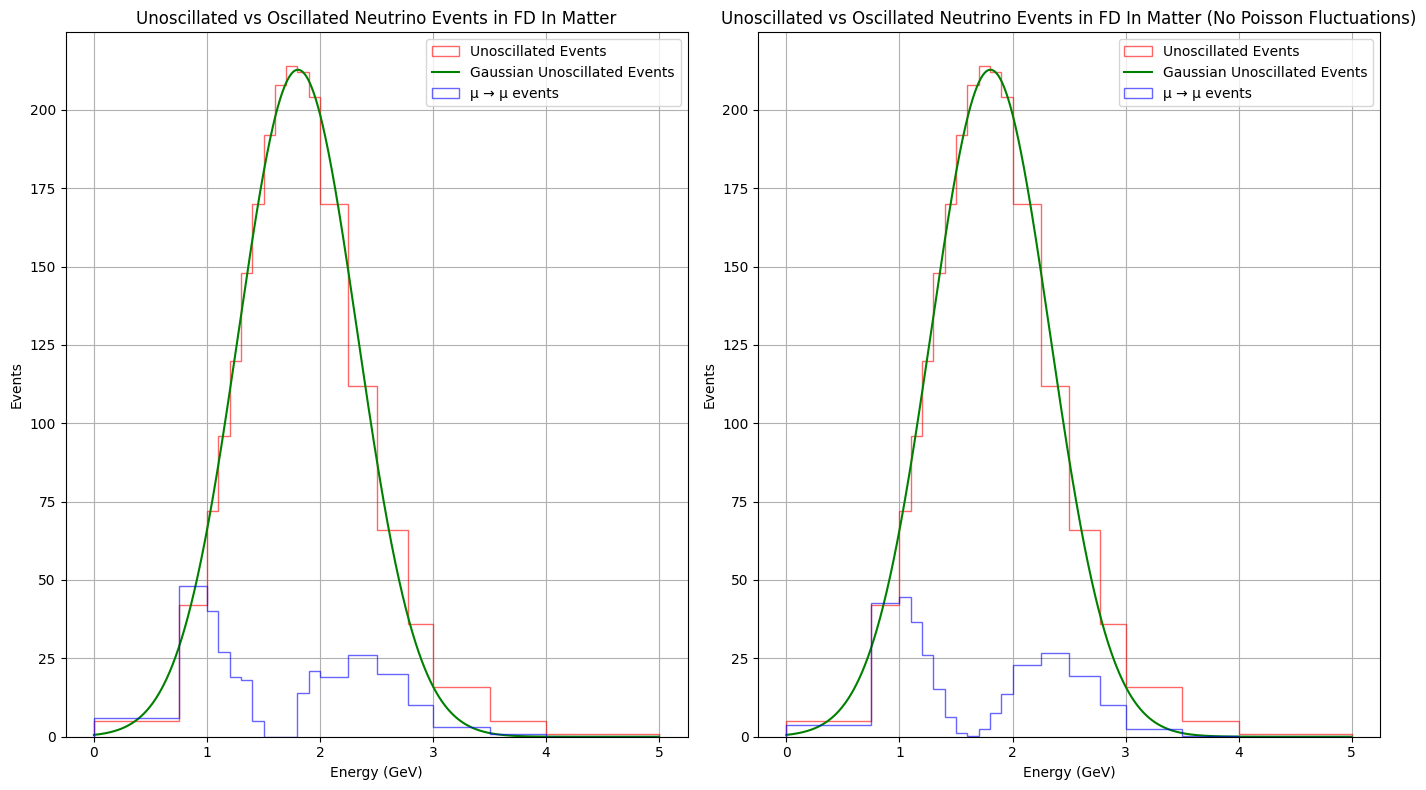

Probabilitities:  [0.3063111538642347, 0.0429004231900409, 0.41409974307577385, 0.625511902597834, 0.7871567941474532, 0.8967465458396428, 0.9620746118477347, 0.9931838563410385, 0.9992907398399894, 0.9878763496020324, 0.964655508828552, 0.9338428717396685, 0.8702794334556176, 0.7739072270638637, 0.6783825250140475, 0.5976171428039698, 0.49927446937380393, 0.3950191315764443, 0.287518827468906]


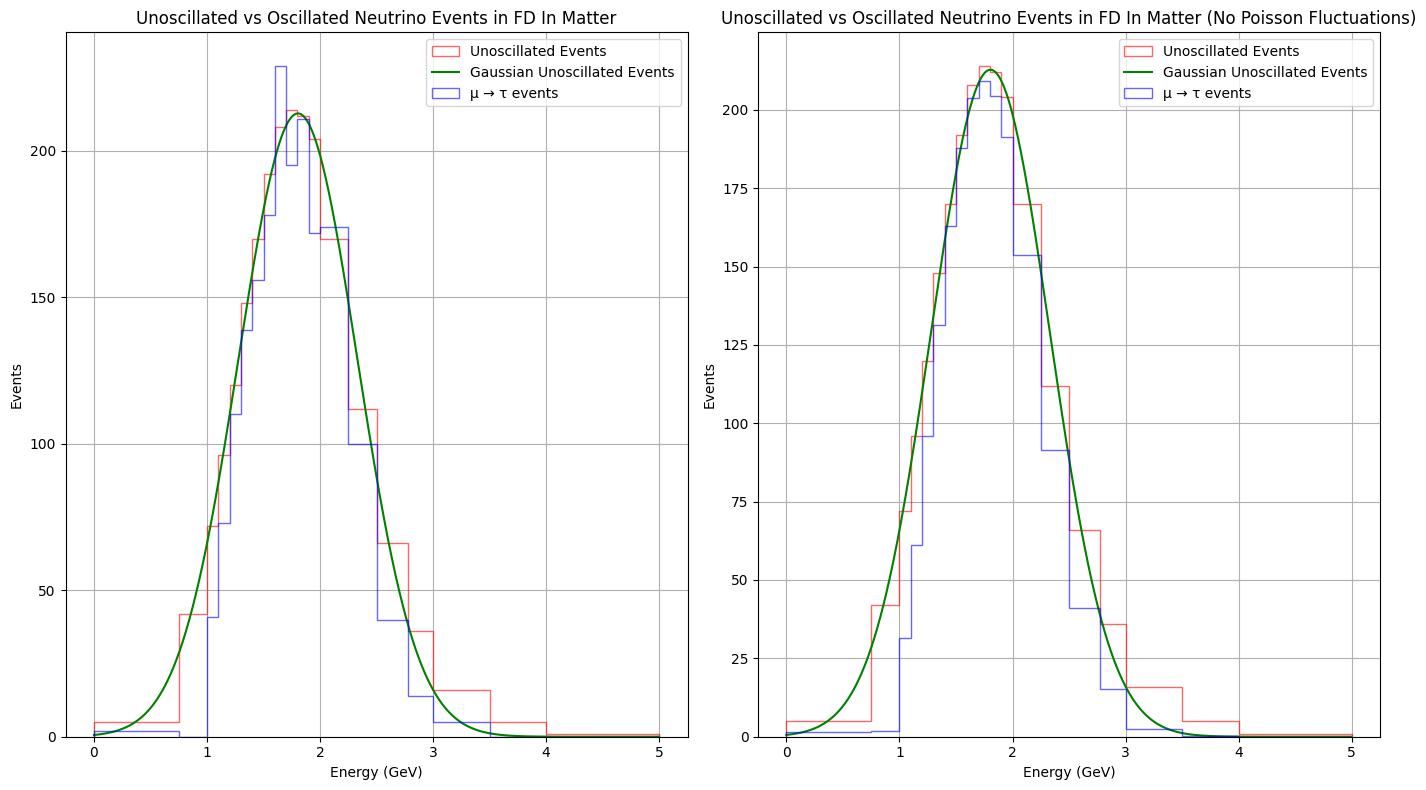

Probabilitities:  [0.03349036599440781, 0.006263506137668121, 0.004356735978246941, 0.0036343957011415883, 0.0030778037975099522, 0.002639888314783717, 0.002289169709131881, 0.002003951356019589, 0.0017688864886633835, 0.0015728724053393774, 0.0014077164201360367, 0.0012672665134932828, 0.0010674228832206957, 0.0008547926991802473, 0.0006932868354264259, 0.0005785460149886903, 0.0004567848662828094, 0.00034317503427046476, 0.00023837358160206347]


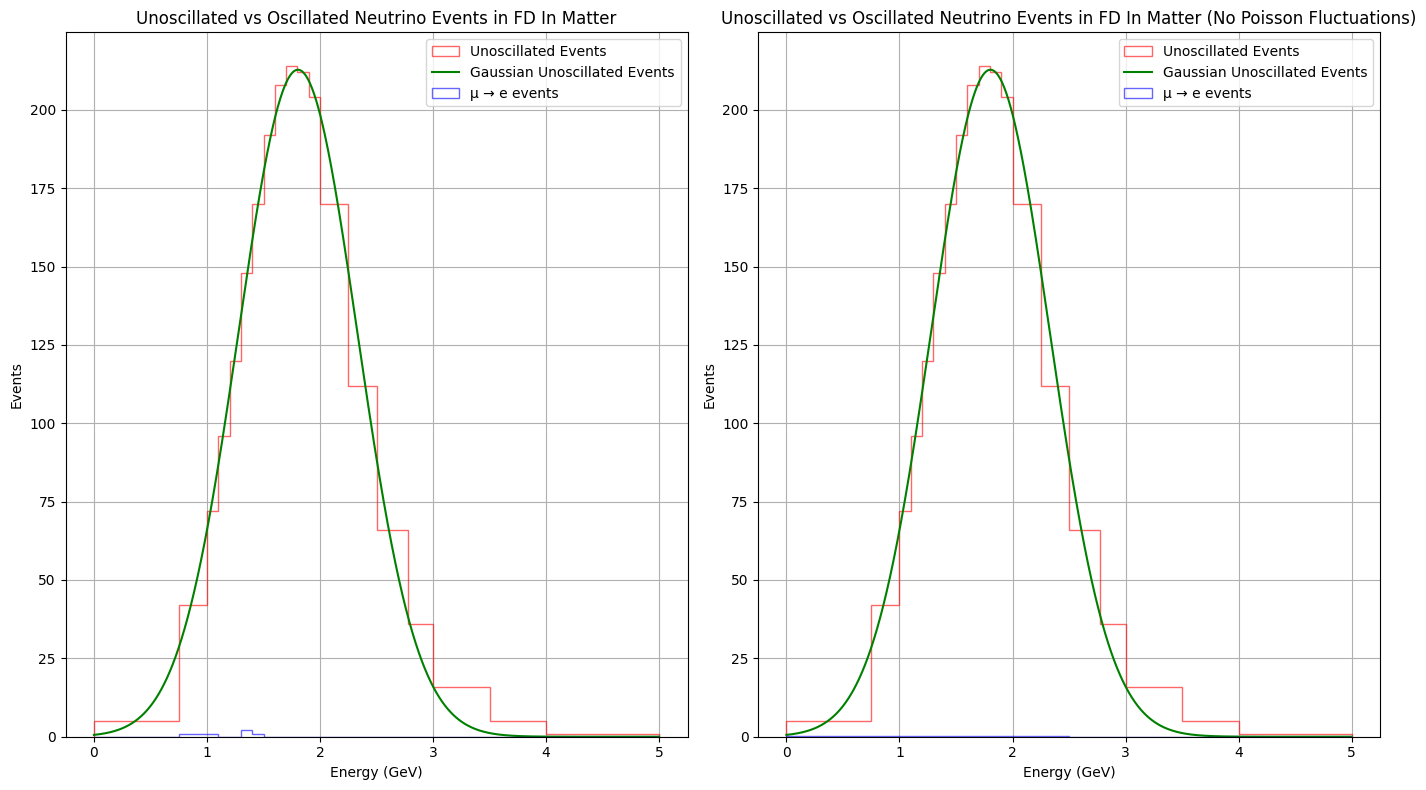

In [10]:
plot_osc_2nu(sector='23', case='matter', length=length_fd, transition='mm')
plot_osc_2nu(sector='23', case='matter', length=length_fd, transition='mt')
plot_osc_2nu(sector='12', case='matter', length=length_fd, transition='me')

In [11]:
def plot_osc_2nu_scaled_fd(sector, case, length,transition):
    """
    Plots the scaled FD oscillation spectrum against simulated FD oscillations.

    Parameters:
    - sector: str, oscillation sector ('12' or '23')
    - case: str, either 'vacuum' or 'matter'
    - length: int, detector length (1, 810)
    - transition: str, type of transition ('me', 'mm', 'mt')
    """

    # Calcualte osc prob
    probabilities = osc_probability_2nu(sector, case, length, transition)
    print(f'Probabilitities: ', probabilities)

    # Set title and labels
    title_text2 = 'In Matter' if case == 'matter' else 'In Vacuum'
    full_title = f'FD Oscillations vs Simulated FD Oscillations {title_text2}'

    label_map = {
        'me': ('μ → e events', 'Gaussian (μ → e) events fit', 2),
        'mt': ('μ → τ events', 'Gaussian (μ → τ) events fit', 2),
        'mm': ('μ → μ events', 'Gaussian (μ → μ) events fit', 0),
    }
    event_label, gaussian_fit_label, index = label_map.get(transition, ('Unknown transition', '', 0))
    
    # Calculate the Poisson-distributed counts for the oscillated events
    counts = poisson_dist(probabilities, bin_centers, *popt_nd)
    unfluc_counts = probabilities * gaus(bin_centers, *popt_nd)
    amount_count = np.sum(unfluc_counts)
    print(amount_count)

    # Calculate scale factor
    scale_factor = np.sum(counts_fd) / np.sum(counts_nd)
    scaled_counts = counts * scale_factor

    # Plotting
    plt.figure(figsize=(12,8))
    
    # FD spectrum histogram
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd, histtype='step',density=False,
             alpha=0.6, color='b', label='Oscillated FD spectrum')

    plt.hist(bin_edges[:-1], bins=bin_edges, weights=scaled_counts, histtype='step',density=False,
             alpha=0.6, color='r', label=event_label)

    # Labels and title to the plot
    plt.xlabel('Energy (GeV)')
    plt.ylabel('Events')
    plt.title(full_title)
    plt.legend()
    plt.grid()
    plt.show()

Probabilitities:  [0.6653307341929288, 0.9687321181467963, 0.621155521490715, 0.4139422689541826, 0.2523328466200332, 0.14044032234507176, 0.07169074747223192, 0.03677751611967128, 0.02689613750418407, 0.034776793974110154, 0.054797882961059696, 0.08277152749360017, 0.142198564280958, 0.23421531669891948, 0.32662760204792696, 0.40538378945036035, 0.5018767392901122, 0.6047768472581979, 0.7114690487256135]
331.5640384282278


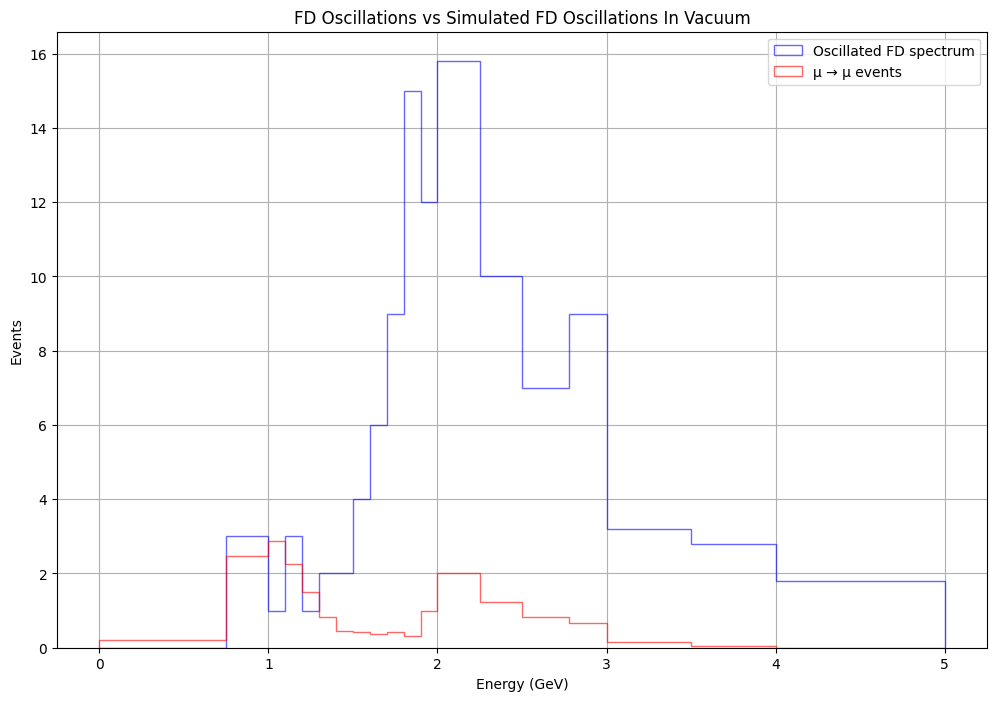

Probabilitities:  [0.33466926580707124, 0.031267881853203706, 0.378844478509285, 0.5860577310458174, 0.7476671533799668, 0.8595596776549282, 0.9283092525277681, 0.9632224838803287, 0.9731038624958159, 0.9652232060258898, 0.9452021170389403, 0.9172284725063998, 0.857801435719042, 0.7657846833010805, 0.673372397952073, 0.5946162105496396, 0.49812326070988777, 0.3952231527418021, 0.28853095127438655]
1736.9010631106546


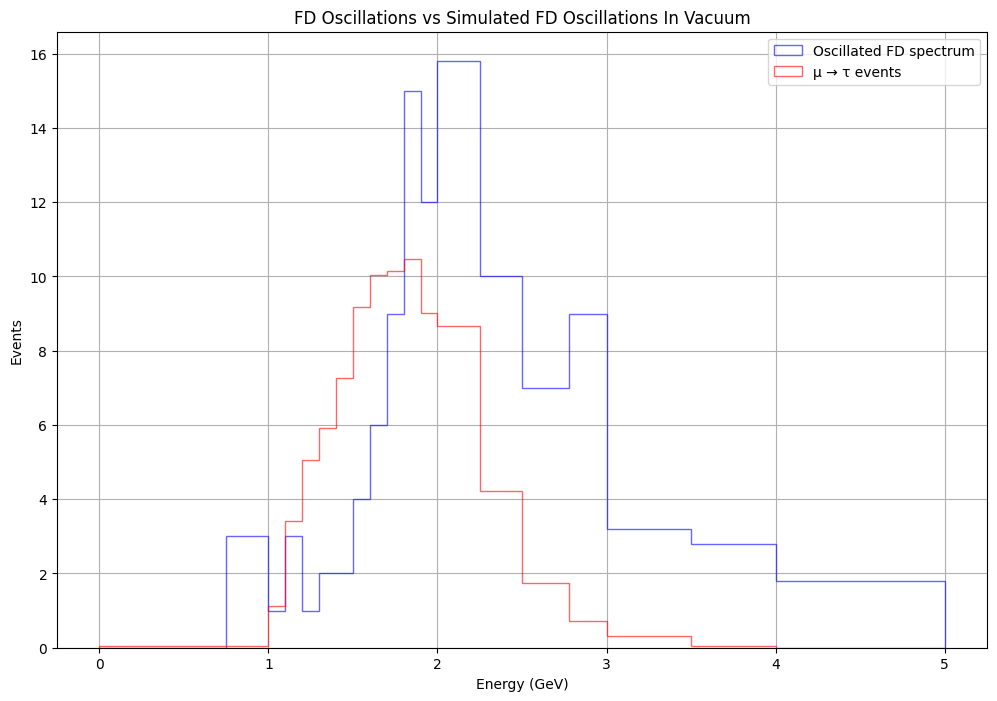

Probabilitities:  [0.034517982761426806, 0.006411103781786138, 0.004455564502644847, 0.003715449117993671, 0.003145456607042997, 0.0026971942324509448, 0.0023383235628732773, 0.002046570316452103, 0.001806187856032761, 0.0016057896908078068, 0.0014369772940009849, 0.0012934464503434578, 0.001089267106492091, 0.0008720910035609608, 0.0007071833359541512, 0.0005900554118094981, 0.00046579100384905016, 0.0003498766037303638, 0.00024297998517533925]
4.363854604882229


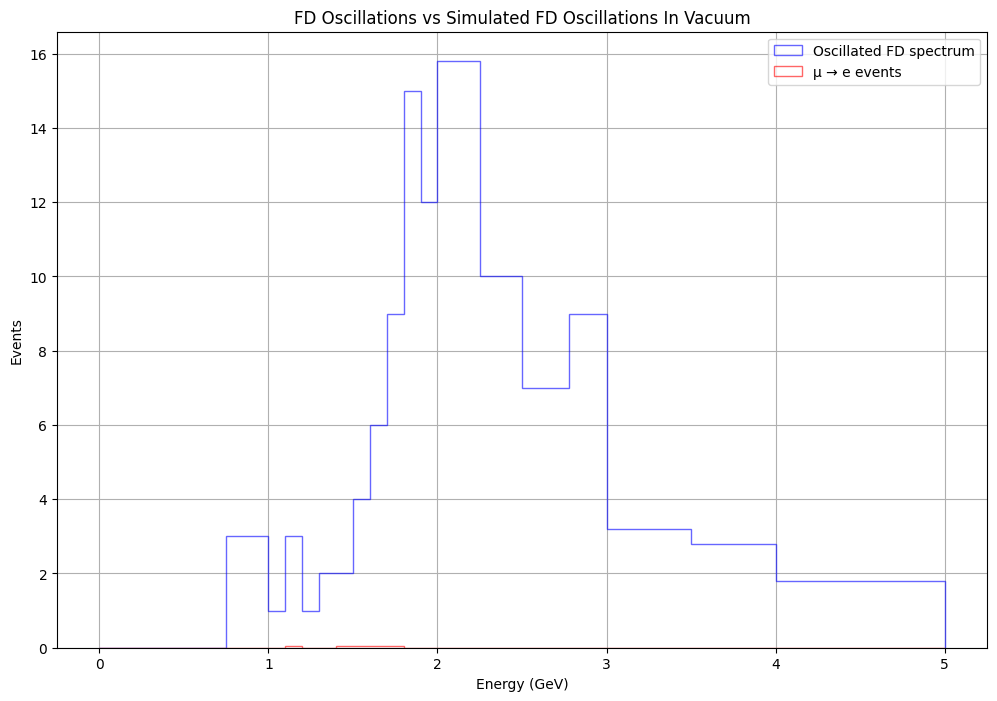

In [12]:
plot_osc_2nu_scaled_fd(sector='23', case='vacuum', length=length_fd, transition='mm')
plot_osc_2nu_scaled_fd(sector='23', case='vacuum', length=length_fd, transition='mt')
plot_osc_2nu_scaled_fd(sector='12', case='vacuum', length=length_fd, transition='me')

Probabilitities:  [0.6936888461357653, 0.957099576809959, 0.5859002569242262, 0.37448809740216604, 0.2128432058525468, 0.10325345416035725, 0.037925388152265316, 0.006816143658961549, 0.0007092601600106052, 0.01212365039796759, 0.035344491171448, 0.06615712826033149, 0.12972056654438235, 0.22609277293613628, 0.3216174749859525, 0.4023828571960302, 0.5007255306261961, 0.6049808684235557, 0.712481172531094]
281.7996886123113


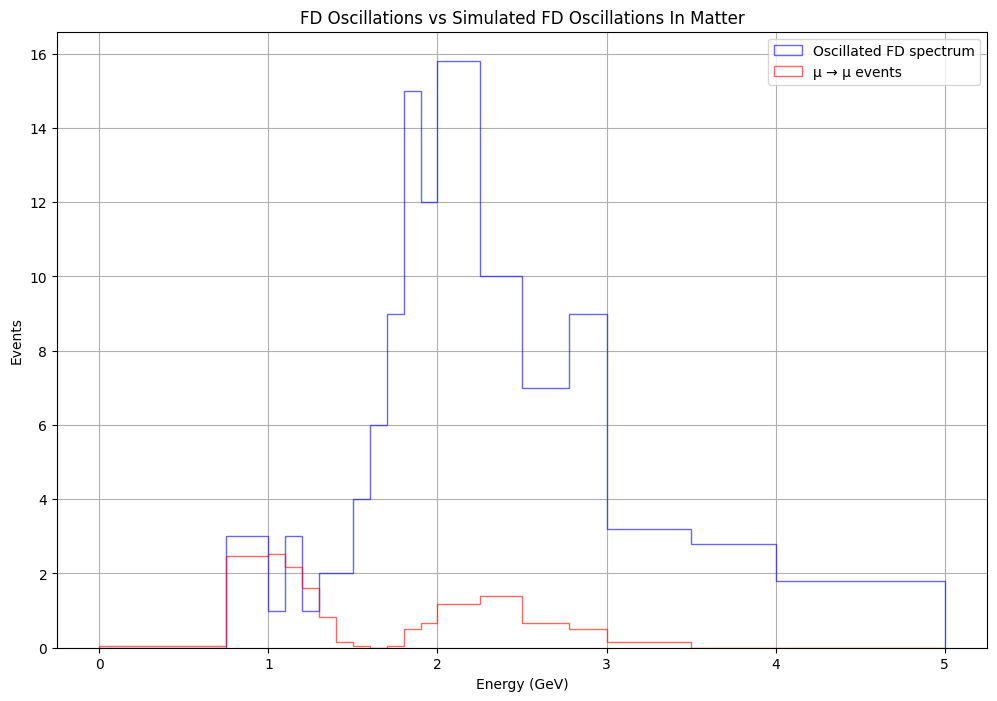

Probabilitities:  [0.3063111538642347, 0.0429004231900409, 0.41409974307577385, 0.625511902597834, 0.7871567941474532, 0.8967465458396428, 0.9620746118477347, 0.9931838563410385, 0.9992907398399894, 0.9878763496020324, 0.964655508828552, 0.9338428717396685, 0.8702794334556176, 0.7739072270638637, 0.6783825250140475, 0.5976171428039698, 0.49927446937380393, 0.3950191315764443, 0.287518827468906]
1786.6654129265712


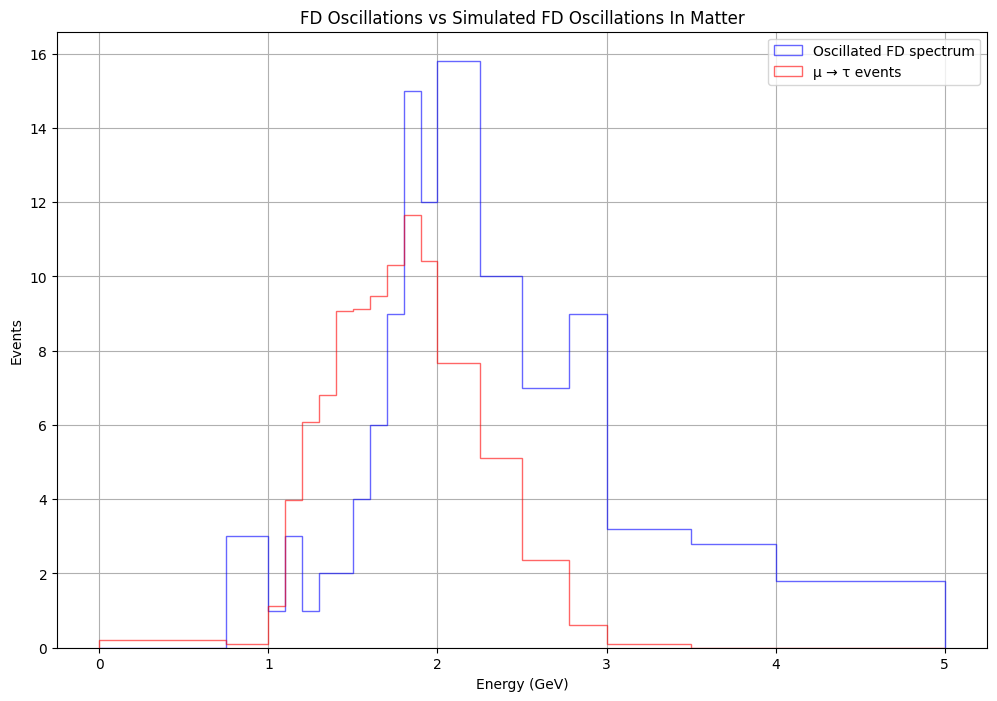

Probabilitities:  [0.03349036599440781, 0.006263506137668121, 0.004356735978246941, 0.0036343957011415883, 0.0030778037975099522, 0.002639888314783717, 0.002289169709131881, 0.002003951356019589, 0.0017688864886633835, 0.0015728724053393774, 0.0014077164201360367, 0.0012672665134932828, 0.0010674228832206957, 0.0008547926991802473, 0.0006932868354264259, 0.0005785460149886903, 0.0004567848662828094, 0.00034317503427046476, 0.00023837358160206347]
4.270195142712477


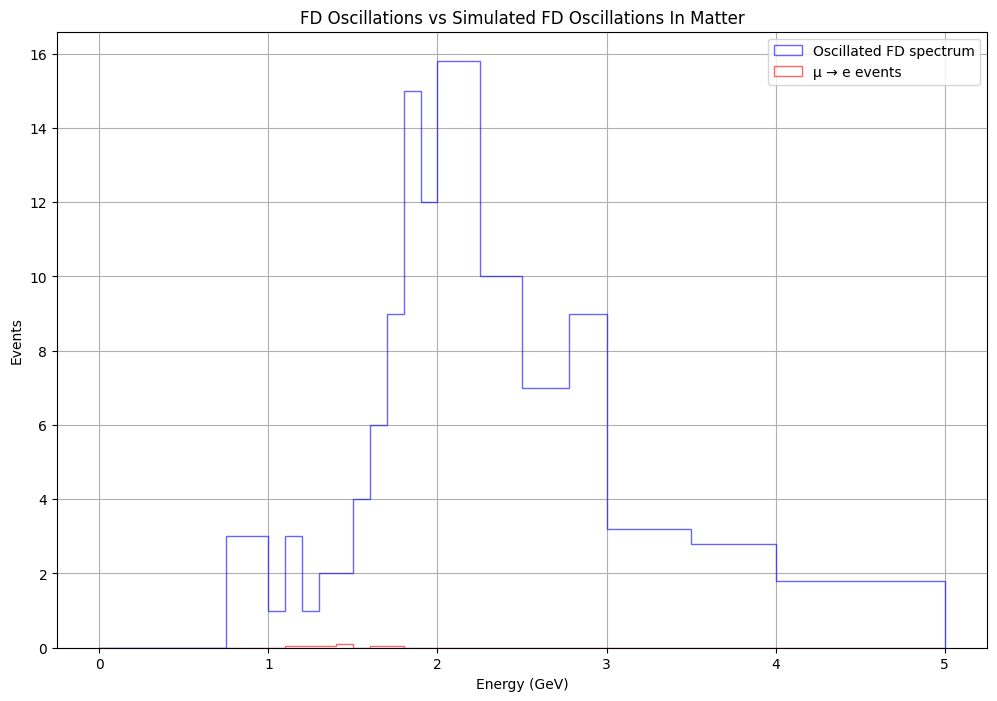

In [13]:
plot_osc_2nu_scaled_fd(sector='23', case='matter', length=length_fd, transition='mm')
plot_osc_2nu_scaled_fd(sector='23', case='matter', length=length_fd, transition='mt')
plot_osc_2nu_scaled_fd(sector='12', case='matter', length=length_fd, transition='me')